# LATAR BELAKANG
FundFusion, sebuah institusi bank di Wakanda, ingin mengembangkan upaya pelayanan marketing-nya terhadap nasabah existing maupun nasabah baru. Salah satu strategi marketing-nya adalah melakukan kampanye berbasis telepon atau telemarketing. Cara kerja strategi tersebut adalah menggunakan media telepon untuk menawarkan kepada nasabah.

Saat ini, FundFusion belum memiliki strategi yang jelas dalam hal penawaran produk ketika menghubungi calon nasabah. Masing-masing account manager memiliki KPI yang berbeda untuk costumer acqusition berdasarkan produk yang ditawarkan oleh FundFusion, seperti tabungan, deposito, kartu kredit, kredit rumah, kredit kendaraan, maupun kredit dana tunai.

Hal ini mengakibatkan calon nasabah sehari dapat dihubungi berulang kali oleh account manager yang berbeda untuk ditawarkan produk yang berbeda pula. Implikasinya, rejection rate yang didapatkan sangat tinggi dan dianggap sebagai spam oleh calon nasabah yang berujung pada pemblokiran nomor.

# PROBLEM STATEMENT
Institusi belum memiliki strategi yang tepat untuk menawarkan jenis produk yang sesuai dengan segmen calon nasabah yang akan direkrut.

# OBJECTIVE
Meningkatkan nasabah baru dengan cara menawarkan produk yang tepat sesuai dengan kriteria calon nasabah yang akan dihubungi.

# VARIABEL YANG TERSEDIA
Dari dataset yang dimiliki terdapat beberapa data yang tersedia:


---
1. **GCIF** : unique identifier nasabah.
2. **Area** : lokasi nasabah (Jakarta, Bogor, Bandung, Surabaya, Jogja, Solo).
3. **Jalur_Pembukaan** : touch points nasabah membuka produk (cabang, telemarketing, aplikasi digital, internet banking).
4. **Vintage**: durasi menjadi nasabah (sejak pembukaan akun).
5. **Usia**: usia nasabah.
6. **Jenis_Kelamin** : Laki-laki (1) dan Perempuan (0).
7. **Status_Perkawinan** : Belum menikah (0), Menikah (1), Cerai (2), Janda/Duda (3).
8. **Jumlah_Anak** : jumlah anak (numerik).
9. **Pendidikan** : status pendidikan terakhir (Tidak memiliki pendidikan formal (0), SD (1), SMP (2), SMA (3), Sarjana (4), Magister (5), Doktor (6)).
10. **Produk_Tabungan** : status kepemilikan produk (yes (1) atau no (0)).
11. **Produk_Deposito** : status kepemilikan produk (yes (1) atau no (0)).
12. **Produk_Kartu_Kredit** : status kepemilikan produk (yes (1) atau no (0)).
13. **Produk_Kredit_Rumah** : status kepemilikan produk (yes (1) atau no (0)).
14. **Produk_Kredit_Kendaraan** : status kepemilikan produk (yes (1) atau no (0)).
15. **Produk_Kredit_Dana_Tunai** : status kepemilikan produk (yes (1) atau no (0)).
16. **Total_Kepemilikan_Produk** : jumlah produk yang dimiliki (penjumlahan dari produk yang dimiliki).
17. **Pendapatan_Tahunan** : rata-rata pendapatan dalam setahun.
18. **Total_Relationship_Balance** : total aset nasabah dalam cutoff bulan observasi.

# EXPERIMENT
Periode Tinjauan:
1. Dikelompokkan berdasarkan demografis untuk dicari pola kepemilikan produk.
2. Dikelompokkan berdasarkan kepemilikan produk untuk dicari pola berdasarkan demografi.


## **Import Package**

In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

In [92]:
pd.set_option('display.max_columns', None)

## **Data for Clustering**

In [93]:
path_1 = "https://raw.githubusercontent.com/brainspopper/dataset/main/clustering_data.csv"
data = pd.read_csv(path_1)
data.dtypes

,0
GCIF,object
Area,object
Jalur_Pembukaan,object
Vintage,object
Usia,float64
Jenis_Kelamin,object
Status_Perkawinan,object
Jumlah_Anak,int64
Pendidikan,object
Produk_Tabungan,int64


## **Data Understanding**

In [94]:
data.groupby(('Area'))['Area'].count()

,Area
Area,
Bandung,6917
Bogor,1191
Jakarta,7017
Jogja,3001
Solo,5001
Surabaya,5002


Dapat terlihat bahwa area yang paling banyak yaitu Bandung dan Jakarta dan area terendah yaitu Bogor

In [95]:
# Select only the numeric columns
numeric_cols = data.select_dtypes(include=['number']).columns
# Group by 'Area' and compute the mean for numeric columns
result = data.groupby('Area')[numeric_cols].mean()
print(data.groupby('Area').mean(numeric_only=True).to_string())

               Usia  Jumlah_Anak  Produk_Tabungan  Produk_Deposito  Produk_Kartu_Kredit  Produk_Kredit_Rumah  Produk_Kredit_Kendaraan  Produk_Kredit_Dana_Tunai  Total_Kepemilikan_Produk  Pendapatan_Tahunan  Total_Relationship_Balance
Area                                                                                                                                                                                                                                     
Bandung   42.562310     1.296516         0.925401         0.599682             0.329767             0.587393                 0.163076                  0.537516                  3.142836          405.124910                2.454722e+08
Bogor     42.660451     1.366919         0.921075         0.596977             0.324097             0.582704                 0.160369                  0.554996                  3.140218          402.227540                2.499853e+08
Jakarta   42.696995     1.322930         0.925467         0.6035

Tidak ada perbedaan signifikan dari rata-rata masing-masing usia, produk, maupun pendapatan tahunan

In [96]:
data.groupby(('Vintage'))['Vintage'].count()

,Vintage
Vintage,
2 - 3 Tahun,13953
< 1 Tahun,9278
> 4 Tahun,4898


In [97]:
# Select only the numeric columns
numeric_cols = data.select_dtypes(include=['number']).columns
# Group by 'Area' and compute the mean for numeric columns
result = data.groupby('Vintage')[numeric_cols].mean()
print(data.groupby('Vintage').mean(numeric_only=True).to_string())

                  Usia  Jumlah_Anak  Produk_Tabungan  Produk_Deposito  Produk_Kartu_Kredit  Produk_Kredit_Rumah  Produk_Kredit_Kendaraan  Produk_Kredit_Dana_Tunai  Total_Kepemilikan_Produk  Pendapatan_Tahunan  Total_Relationship_Balance
Vintage                                                                                                                                                                                                                                     
2 - 3 Tahun  42.578850     1.291694         0.927256         0.607755             0.328531             0.589336                 0.163764                  0.539311                  3.155952          407.679639                2.489367e+08
< 1 Tahun    42.689341     1.294676         0.931235         0.592585             0.336495             0.594201                 0.164798                  0.523389                  3.142703          395.611231                2.486679e+08
> 4 Tahun    42.571866     1.338301         0.912822

Dapat dilihat dari rata-rata masing-masingnya belum menunjukkan perbedaan yang signifikan. Namun, pada pendapatan terlihat sedikit bervariasi dibanding dilihat dari sisi usia, terlihat bahwa pengguna baru memiliki pendapatan yang lebih rendah dibanding dengan pengguna yang lebih lama, ini menunjukkan kemungkinan pengguna baru Bank merupakan orang yang baru mendapatkan pekerjaan.

In [98]:
data.groupby(('Jalur_Pembukaan'))['Jalur_Pembukaan'].count()

,Jalur_Pembukaan
Jalur_Pembukaan,
Aplikasi Digital,6216
Cabang,5856
Internet Banking,5795
Telemarketing,10262


Dilihat bahwa pengguna Bank membuka akun kebanyakan melalui Telemarketing.

In [99]:
# Select only the numeric columns
numeric_cols = data.select_dtypes(include=['number']).columns
# Group by 'Area' and compute the mean for numeric columns
result = data.groupby('Jalur_Pembukaan')[numeric_cols].mean()
print(data.groupby('Jalur_Pembukaan').mean(numeric_only=True).to_string())

                       Usia  Jumlah_Anak  Produk_Tabungan  Produk_Deposito  Produk_Kartu_Kredit  Produk_Kredit_Rumah  Produk_Kredit_Kendaraan  Produk_Kredit_Dana_Tunai  Total_Kepemilikan_Produk  Pendapatan_Tahunan  Total_Relationship_Balance
Jalur_Pembukaan                                                                                                                                                                                                                                  
Aplikasi Digital  42.442089     1.292149         0.930180         0.598456             0.323681             0.593147                 0.165541                  0.535714                  3.146718          405.278314                2.489950e+08
Cabang            42.560627     1.308743         0.924180         0.610143             0.325478             0.583675                 0.153518                  0.544740                  3.141735          409.923156                2.456661e+08
Internet Banking  42.723992     

Masih belum terlihat perbedaan yang signifikan

In [100]:
data.groupby(('Status_Perkawinan'))['Status_Perkawinan'].count()

,Status_Perkawinan
Status_Perkawinan,
Belum Menikah,8168
Cerai,4077
Janda/Duda,4045
Menikah,11839


Jika dilihat dari status perkawinan, nasabah kebanyakan adalah orang yang sudah menikah

In [101]:
# Select only the numeric columns
numeric_cols = data.select_dtypes(include=['number']).columns
# Group by 'Area' and compute the mean for numeric columns
result = data.groupby('Status_Perkawinan')[numeric_cols].mean()
print(data.groupby('Status_Perkawinan').mean(numeric_only=True).to_string())

                        Usia  Jumlah_Anak  Produk_Tabungan  Produk_Deposito  Produk_Kartu_Kredit  Produk_Kredit_Rumah  Produk_Kredit_Kendaraan  Produk_Kredit_Dana_Tunai  Total_Kepemilikan_Produk  Pendapatan_Tahunan  Total_Relationship_Balance
Status_Perkawinan                                                                                                                                                                                                                                 
Belum Menikah      39.571621     0.000000         1.000000         0.596107             0.333374             0.331660                 0.160749                  0.499633                  2.921523          420.636141                2.423448e+08
Cerai              50.226883     2.003679         1.000000         0.607555             0.337258             0.509688                 0.172676                  0.389747                  3.016924          426.269070                2.393499e+08
Janda/Duda               NaN

Secara usia terlihat bahwa nasabah yang janda/duda memiliki missing data. Sedangkan untuk kepemilikan produk ada sedikit variasi di beberapa segmen seperti yang terlihat di kredit dana tunai, nasabah yang sudah menikah memiliki kredit dana tunai yang lebih tinggi yang mungkin digunakan untuk keperluan rumah tangga. Pendapatan yang berstatus janda/duda cukup rendah dibanding kategori yang lain, karena bernilai NaN pada usia, sehingga kita tidak dapat melihat apakah alasan kecilnya rata-rata pendapatan dikarenakan usia apakah karena hal lain.

##**Data Preparation**
## Pengecekan Data Duplikat dan *Missing Data*

In [102]:
data.isnull().sum()

,0
GCIF,0
Area,0
Jalur_Pembukaan,0
Vintage,0
Usia,4045
Jenis_Kelamin,0
Status_Perkawinan,0
Jumlah_Anak,0
Pendidikan,0
Produk_Tabungan,0


Pada kolom usia terdapat nilai hilang, sesuai dengan analisis yang kita dapatkan pada bagian status janda/duda yang bernilai NaN.

In [103]:
#Membuang nilai yang hilang
data = data.dropna()

In [104]:
data.isnull().sum()

,0
GCIF,0
Area,0
Jalur_Pembukaan,0
Vintage,0
Usia,0
Jenis_Kelamin,0
Status_Perkawinan,0
Jumlah_Anak,0
Pendidikan,0
Produk_Tabungan,0


In [105]:
#data duplikat
data.duplicated().sum()

0

## Pengecekan Data Outlier

In [106]:
data.count()

,0
GCIF,24084
Area,24084
Jalur_Pembukaan,24084
Vintage,24084
Usia,24084
Jenis_Kelamin,24084
Status_Perkawinan,24084
Jumlah_Anak,24084
Pendidikan,24084
Produk_Tabungan,24084


In [107]:
#Mendeteksi dan mengatasi outlier (misal dibagi dengan Z-score)
from scipy import stats
z_scores =stats.zscore(data[['Usia', 'Pendapatan_Tahunan', 'Total_Relationship_Balance']])
data = data[(z_scores < 3).all(axis=1)] #menghapus z-score > 3

In [108]:
data.count()

,0
GCIF,23704
Area,23704
Jalur_Pembukaan,23704
Vintage,23704
Usia,23704
Jenis_Kelamin,23704
Status_Perkawinan,23704
Jumlah_Anak,23704
Pendidikan,23704
Produk_Tabungan,23704


## Filtering data telemarketing only

In [109]:
data0 = data[data['Jalur_Pembukaan']=='Telemarketing']

In [110]:
data0 = data0.drop(columns=['GCIF', 'Jalur_Pembukaan']).reset_index(drop=True)
data0 = data0.reset_index()
data0.head()

,index,Area,Vintage,Usia,Jenis_Kelamin,Status_Perkawinan,Jumlah_Anak,Pendidikan,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
0,0,Jakarta,< 1 Tahun,23.0,Laki-laki,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,198,10668586
1,1,Surabaya,< 1 Tahun,30.0,Laki-laki,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,280,299076075
2,2,Solo,< 1 Tahun,29.0,Laki-laki,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,295,76653088
3,3,Jakarta,< 1 Tahun,49.0,Laki-laki,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,443,247157199
4,4,Jakarta,< 1 Tahun,21.0,Perempuan,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,257,27585562


## Pembagian Dataset Experiment

1. Eksperimen 0: semua variabel digunakan.
2. Eksperimen 1: menggunakan demographics.
3. Eksperimen 2: menggunakan financial related variable.

In [111]:
data1 = data0.iloc[:, 1:8] #Area-Pendidikan

In [112]:
data1

,Area,Vintage,Usia,Jenis_Kelamin,Status_Perkawinan,Jumlah_Anak,Pendidikan
0,Jakarta,< 1 Tahun,23.0,Laki-laki,Belum Menikah,0,Doktor
1,Surabaya,< 1 Tahun,30.0,Laki-laki,Belum Menikah,0,Doktor
2,Solo,< 1 Tahun,29.0,Laki-laki,Belum Menikah,0,Doktor
3,Jakarta,< 1 Tahun,49.0,Laki-laki,Belum Menikah,0,Doktor
4,Jakarta,< 1 Tahun,21.0,Perempuan,Belum Menikah,0,Doktor
...,...,...,...,...,...,...,...
8648,Bandung,2 - 3 Tahun,54.0,Laki-laki,Menikah,0,Tidak Sekolah Formal
8649,Jakarta,2 - 3 Tahun,58.0,Laki-laki,Belum Menikah,0,Tidak Sekolah Formal
8650,Bandung,2 - 3 Tahun,42.0,Laki-laki,Cerai,3,Tidak Sekolah Formal
8651,Jogja,2 - 3 Tahun,44.0,Laki-laki,Cerai,1,Tidak Sekolah Formal


In [113]:
data2 = data0.iloc[:, 8:17] #Produk Tabungan-Total_Relationship_Balance

In [114]:
data2

,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
0,1,0,0,0,0,0,1,198,10668586
1,1,0,0,0,0,0,1,280,299076075
2,1,0,0,0,0,0,1,295,76653088
3,1,0,0,0,0,0,1,443,247157199
4,1,0,0,0,0,0,1,257,27585562
...,...,...,...,...,...,...,...,...,...
8648,1,1,1,1,0,1,5,489,321693904
8649,1,1,1,1,1,0,5,658,224477967
8650,1,1,1,1,0,1,5,585,411871605
8651,1,1,0,1,1,1,5,279,161744694


## Melakukan encoding data category

In [115]:
#mengubah data kategorikal
data1 = pd.get_dummies(data1, columns=['Area', 'Jenis_Kelamin', 'Status_Perkawinan', 'Pendidikan', 'Vintage'])
data1.head()

,Usia,Jumlah_Anak,Area_Bandung,Area_Bogor,Area_Jakarta,Area_Jogja,Area_Solo,Area_Surabaya,Jenis_Kelamin_Laki-laki,Jenis_Kelamin_Perempuan,Status_Perkawinan_Belum Menikah,Status_Perkawinan_Cerai,Status_Perkawinan_Menikah,Pendidikan_Doktor,Pendidikan_Magister,Pendidikan_SD,Pendidikan_SMA,Pendidikan_SMP,Pendidikan_Sarjana,Pendidikan_Tidak Sekolah Formal,Vintage_2 - 3 Tahun,Vintage_< 1 Tahun,Vintage_> 4 Tahun
0,23.0,0,False,False,True,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,True,False
1,30.0,0,False,False,False,False,False,True,True,False,True,False,False,True,False,False,False,False,False,False,False,True,False
2,29.0,0,False,False,False,False,True,False,True,False,True,False,False,True,False,False,False,False,False,False,False,True,False
3,49.0,0,False,False,True,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,True,False
4,21.0,0,False,False,True,False,False,False,False,True,True,False,False,True,False,False,False,False,False,False,False,True,False


## Standardisasi data numerik

In [116]:
predname_num = data2.columns
predname_num

Index(['Produk_Tabungan', 'Produk_Deposito', 'Produk_Kartu_Kredit',
       'Produk_Kredit_Rumah', 'Produk_Kredit_Kendaraan',
       'Produk_Kredit_Dana_Tunai', 'Total_Kepemilikan_Produk',
       'Pendapatan_Tahunan', 'Total_Relationship_Balance'],
      dtype='object')

In [117]:
from sklearn.preprocessing import StandardScaler
pt = StandardScaler()
X_num = pd.DataFrame(pt.fit_transform(data2))
X_num.head()

,0,1,2,3,4,5,6,7,8
0,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-1.256170,-1.607805
1,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.800973,0.410538
2,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.717705,-1.146030
3,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,0.103871,0.047197
4,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.928650,-1.489416


In [118]:
X_num.columns = predname_num
X_num.head()

,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
0,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-1.256170,-1.607805
1,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.800973,0.410538
2,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.717705,-1.146030
3,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,0.103871,0.047197
4,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.928650,-1.489416


## Pengecekan Korelasi

In [119]:
corrtest1 = data1.corr().abs()
corrtest2 = X_num.corr().abs()

In [120]:
corrtest1

,Usia,Jumlah_Anak,Area_Bandung,Area_Bogor,Area_Jakarta,Area_Jogja,Area_Solo,Area_Surabaya,Jenis_Kelamin_Laki-laki,Jenis_Kelamin_Perempuan,Status_Perkawinan_Belum Menikah,Status_Perkawinan_Cerai,Status_Perkawinan_Menikah,Pendidikan_Doktor,Pendidikan_Magister,Pendidikan_SD,Pendidikan_SMA,Pendidikan_SMP,Pendidikan_Sarjana,Pendidikan_Tidak Sekolah Formal,Vintage_2 - 3 Tahun,Vintage_< 1 Tahun,Vintage_> 4 Tahun
Usia,1.000000,0.105752,0.015472,0.010122,0.000703,0.004196,0.009153,0.000800,0.022998,0.022998,0.182525,0.269976,0.027666,0.019497,0.002532,0.017649,0.007478,0.000769,0.009315,0.023562,0.009375,0.014677,0.005059
Jumlah_Anak,0.105752,1.000000,0.004419,0.008073,0.006375,0.003399,0.000538,0.020592,0.004123,0.004123,0.637109,0.210638,0.448296,0.010529,0.012402,0.002656,0.005471,0.004266,0.001571,0.012021,0.012883,0.000549,0.015414
Area_Bandung,0.015472,0.004419,1.000000,0.075688,0.434134,0.129781,0.165969,0.173396,0.005038,0.005038,0.001969,0.004996,0.001850,0.004182,0.018846,0.009738,0.008150,0.008533,0.002294,0.003398,0.004687,0.007997,0.003280
Area_Bogor,0.010122,0.008073,0.075688,1.000000,0.160824,0.048077,0.061483,0.064234,0.017781,0.017781,0.017977,0.007205,0.011709,0.014371,0.018786,0.005275,0.019397,0.005195,0.001137,0.011784,0.006728,0.011535,0.004774
Area_Jakarta,0.000703,0.006375,0.434134,0.160824,1.000000,0.275762,0.352656,0.368437,0.016156,0.016156,0.003612,0.000622,0.002968,0.006520,0.004666,0.005406,0.001637,0.021187,0.003183,0.004680,0.000667,0.002865,0.002436
Area_Jogja,0.004196,0.003399,0.129781,0.048077,0.275762,1.000000,0.105423,0.110141,0.000914,0.000914,0.004833,0.011100,0.003675,0.001621,0.012903,0.014696,0.005862,0.002432,0.017757,0.003543,0.001066,0.001924,0.000867
Area_Solo,0.009153,0.000538,0.165969,0.061483,0.352656,0.105423,1.000000,0.140853,0.001620,0.001620,0.018026,0.001115,0.016291,0.012661,0.008184,0.002844,0.000952,0.013671,0.004444,0.016788,0.023666,0.008069,0.020266
Area_Surabaya,0.000800,0.020592,0.173396,0.064234,0.368437,0.110141,0.140853,1.000000,0.010665,0.010665,0.026844,0.018072,0.012041,0.006102,0.019120,0.014693,0.010579,0.004389,0.011413,0.008367,0.024732,0.008411,0.021204
Jenis_Kelamin_Laki-laki,0.022998,0.004123,0.005038,0.017781,0.016156,0.000914,0.001620,0.010665,1.000000,1.000000,0.008398,0.014166,0.018525,0.011471,0.003639,0.010552,0.001215,0.017649,0.010154,0.002050,0.000872,0.006728,0.006585
Jenis_Kelamin_Perempuan,0.022998,0.004123,0.005038,0.017781,0.016156,0.000914,0.001620,0.010665,1.000000,1.000000,0.008398,0.014166,0.018525,0.011471,0.003639,0.010552,0.001215,0.017649,0.010154,0.002050,0.000872,0.006728,0.006585


In [121]:
corrtest2

,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
Produk_Tabungan,1.000000,0.014734,0.034623,0.139139,0.008027,0.077088,0.153869,0.291752,0.004527
Produk_Deposito,0.014734,1.000000,0.016782,0.006236,0.001566,0.006622,0.460055,0.004554,0.059145
Produk_Kartu_Kredit,0.034623,0.016782,1.000000,0.008642,0.021552,0.019652,0.413171,0.018990,0.079988
Produk_Kredit_Rumah,0.139139,0.006236,0.008642,1.000000,0.019383,0.057235,0.456175,0.024236,0.068262
Produk_Kredit_Kendaraan,0.008027,0.001566,0.021552,0.019383,1.000000,0.023933,0.324242,0.000427,0.094714
Produk_Kredit_Dana_Tunai,0.077088,0.006622,0.019652,0.057235,0.023933,1.000000,0.464110,0.000056,0.077747
Total_Kepemilikan_Produk,0.153869,0.460055,0.413171,0.456175,0.324242,0.464110,1.000000,0.062893,0.168432
Pendapatan_Tahunan,0.291752,0.004554,0.018990,0.024236,0.000427,0.000056,0.062893,1.000000,0.004261
Total_Relationship_Balance,0.004527,0.059145,0.079988,0.068262,0.094714,0.077747,0.168432,0.004261,1.000000


In [122]:
#Membuang nilai redundan pada matriks
upper1 = corrtest1.where(np.triu(np.ones(corrtest1.shape), k=1).astype(bool))
upper2 = corrtest2.where(np.triu(np.ones(corrtest2.shape), k=1).astype(bool))

#Mencari nilai yang berkorelasi di atas 0.7
to_drop1 = [column for column in upper1.columns if any(upper1[column] > 0.7)]
to_drop2 = [column for column in upper2.columns if any(upper2[column] > 0.7)]

#menghapus kolom yang korelasinya >0.7
data1 = data1.drop(to_drop1, axis=1)
data2 = data1.drop(to_drop2, axis=1)

In [123]:
data1

,Usia,Jumlah_Anak,Area_Bandung,Area_Bogor,Area_Jakarta,Area_Jogja,Area_Solo,Area_Surabaya,Jenis_Kelamin_Laki-laki,Status_Perkawinan_Belum Menikah,Status_Perkawinan_Cerai,Pendidikan_Doktor,Pendidikan_Magister,Pendidikan_SD,Pendidikan_SMA,Pendidikan_SMP,Pendidikan_Sarjana,Pendidikan_Tidak Sekolah Formal,Vintage_2 - 3 Tahun,Vintage_< 1 Tahun,Vintage_> 4 Tahun
0,23.0,0,False,False,True,False,False,False,True,True,False,True,False,False,False,False,False,False,False,True,False
1,30.0,0,False,False,False,False,False,True,True,True,False,True,False,False,False,False,False,False,False,True,False
2,29.0,0,False,False,False,False,True,False,True,True,False,True,False,False,False,False,False,False,False,True,False
3,49.0,0,False,False,True,False,False,False,True,True,False,True,False,False,False,False,False,False,False,True,False
4,21.0,0,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8648,54.0,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False
8649,58.0,0,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,True,True,False,False
8650,42.0,3,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,True,False,False
8651,44.0,1,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,True,False,False


In [124]:
X_num

,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
0,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-1.256170,-1.607805
1,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.800973,0.410538
2,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.717705,-1.146030
3,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,0.103871,0.047197
4,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.928650,-1.489416
...,...,...,...,...,...,...,...,...,...
8648,0.315645,0.819409,1.437451,0.844468,-0.436158,0.891338,1.797748,0.359225,0.568823
8649,0.315645,0.819409,1.437451,0.844468,2.292747,-1.121909,1.797748,1.297376,-0.111517
8650,0.315645,0.819409,1.437451,0.844468,-0.436158,0.891338,1.797748,0.892139,1.199907
8651,0.315645,0.819409,-0.695676,0.844468,2.292747,0.891338,1.797748,-0.806524,-0.550539


## Menggabungkan data1 dan X_num

In [125]:
data_combined = pd.concat([data1, X_num], axis=1, join='inner')
data_combined

,Usia,Jumlah_Anak,Area_Bandung,Area_Bogor,Area_Jakarta,Area_Jogja,Area_Solo,Area_Surabaya,Jenis_Kelamin_Laki-laki,Status_Perkawinan_Belum Menikah,Status_Perkawinan_Cerai,Pendidikan_Doktor,Pendidikan_Magister,Pendidikan_SD,Pendidikan_SMA,Pendidikan_SMP,Pendidikan_Sarjana,Pendidikan_Tidak Sekolah Formal,Vintage_2 - 3 Tahun,Vintage_< 1 Tahun,Vintage_> 4 Tahun,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
0,23.0,0,False,False,True,False,False,False,True,True,False,True,False,False,False,False,False,False,False,True,False,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-1.256170,-1.607805
1,30.0,0,False,False,False,False,False,True,True,True,False,True,False,False,False,False,False,False,False,True,False,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.800973,0.410538
2,29.0,0,False,False,False,False,True,False,True,True,False,True,False,False,False,False,False,False,False,True,False,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.717705,-1.146030
3,49.0,0,False,False,True,False,False,False,True,True,False,True,False,False,False,False,False,False,False,True,False,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,0.103871,0.047197
4,21.0,0,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.928650,-1.489416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8648,54.0,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,0.315645,0.819409,1.437451,0.844468,-0.436158,0.891338,1.797748,0.359225,0.568823
8649,58.0,0,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,True,True,False,False,0.315645,0.819409,1.437451,0.844468,2.292747,-1.121909,1.797748,1.297376,-0.111517
8650,42.0,3,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,True,False,False,0.315645,0.819409,1.437451,0.844468,-0.436158,0.891338,1.797748,0.892139,1.199907
8651,44.0,1,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,True,False,False,0.315645,0.819409,-0.695676,0.844468,2.292747,0.891338,1.797748,-0.806524,-0.550539


## **Modeling & Evaluation**

Pembangunan model akan menggunakan 2 algoritma:

1. K-Means
2. K-Medoid

dengan pengecekan silhouette score.

## K-Means

In [126]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

## Eksperimen 0

In [127]:
#Variasi hyperparameter (jumlah cluster)
for n_clusters in range(3,6): #yang akan dimasukkan yaitu cluster 3,4,5
  kmeans = KMeans(n_clusters = n_clusters, random_state=0)
  cluster_labels = kmeans.fit_predict(data_combined) #pembuatan model
  silhouette_avg = silhouette_score(data_combined, cluster_labels)
  print("Silhoutte Score (K-Means) -" + str(n_clusters) +" :"+ str(silhouette_avg))
  data0["Clustering_Kmeans_Exp0_" + str(n_clusters)] = cluster_labels

Silhoutte Score (K-Means) -3 :0.43731081737346444
Silhoutte Score (K-Means) -4 :0.37992431452339676
Silhoutte Score (K-Means) -5 :0.3231396807582395


Pada eksperimen 0 hasil Silhoutte Score mendekati 0 yang artinya terdapat titik-titik tumpang tindih

## Eksperimen 1

In [128]:
for n_clusters in range(3,6):
  kmeans = KMeans(n_clusters = n_clusters, random_state=0)
  cluster_labels = kmeans.fit_predict(data1)
  silhoutte_avg = silhouette_score(data1, cluster_labels)
  print("Silhoutte Score (K-Means) -" + str(n_clusters) +" :" +str(silhoutte_avg))
  data0["Clustering_Kmeans_Exp1_" + str(n_clusters)] = cluster_labels

Silhoutte Score (K-Means) -3 :0.5021981273872203
Silhoutte Score (K-Means) -4 :0.48877557780538605
Silhoutte Score (K-Means) -5 :0.4210233962025565


Pada eksperimen 1 hasil Silhoutte Score jika dibandingkan pada eksperimen 0 jauh lebih baik

## EKsperimen 2

In [129]:
for n_clusters in range(3,6):
  kmeans = KMeans(n_clusters = n_clusters, random_state=0)
  cluster_labels = kmeans.fit_predict(X_num)
  silhoutte_avg = silhouette_score(X_num, cluster_labels)
  print("Silhoutte Score (K-Means) -" + str(n_clusters) +" :" +str(silhoutte_avg))
  data0["Clustering_Kmeans_Exp2_" + str(n_clusters)] = cluster_labels

Silhoutte Score (K-Means) -3 :0.17568395122545125
Silhoutte Score (K-Means) -4 :0.17500826370194086
Silhoutte Score (K-Means) -5 :0.18806929666647304


Pada eksperimen 2 hasil Silhoutte Score jika dibandingkan pada eksperimen sebelumnya lebih buruk

## K-Medoids

In [130]:
!pip install scikit-learn-extra

In [131]:
from sklearn_extra.cluster import KMedoids

## Eksperimen 0

In [132]:
for n_clusters in range(3,6):
  kmedoids = KMedoids(n_clusters = n_clusters, random_state=0)
  cluster_labels = kmedoids.fit_predict(data_combined)
  silhoutte_avg = silhouette_score(data_combined, cluster_labels)
  print("Silhoutte Score (K-Means) -" + str(n_clusters) +" :" + str(silhoutte_avg))
  data0["Clustering_Kmedoids_Exp0_" + str(n_clusters)] = cluster_labels

Silhoutte Score (K-Means) -3 :0.43369790762336996
Silhoutte Score (K-Means) -4 :0.33519427927551565
Silhoutte Score (K-Means) -5 :0.3211940252247904


Jika dibandingkan dengan K-Means, hasil menggunakan K-Medoids masih lebih buruk

## Eksperimen 1

In [133]:
for n_clusters in range(3,6):
  kmedoids = KMedoids(n_clusters = n_clusters, random_state=0)
  cluster_labels = kmedoids.fit_predict(data1)
  silhouette_avg = silhouette_score(data1, cluster_labels)
  print("Silhoutte Score (K-Means) -" + str(n_clusters) +" :"+ str(silhouette_avg))
  data0["Clustering_Kmedoids_Exp0_" + str(n_clusters)] = cluster_labels

/usr/local/lib/python3.11/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(


Silhoutte Score (K-Means) -3 :0.0050675633465087746


/usr/local/lib/python3.11/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(


Silhoutte Score (K-Means) -4 :0.4657942038387023


/usr/local/lib/python3.11/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(


Silhoutte Score (K-Means) -5 :0.4178025801646672


## Eksperimen 2

In [134]:
for n_clusters in range(3,6):
  kmedoids = KMedoids(n_clusters = n_clusters, random_state=0)
  cluster_labels = kmedoids.fit_predict(X_num)
  silhouette_avg = silhouette_score(X_num, cluster_labels)
  print("Silhoutte Score (K-Means) -" + str(n_clusters) +" :"+ str(silhouette_avg))
  data0["Clustering_Kmedoids_Exp0_" + str(n_clusters)] = cluster_labels

Silhoutte Score (K-Means) -3 :0.11659038864364947
Silhoutte Score (K-Means) -4 :0.09680611087667028
Silhoutte Score (K-Means) -5 :0.08883545658405254


Dari beberapa eksperimen, yang paling baik adalah hasil model menggunakan K-Means pada data1 dengan 3 cluster

## Analisis Data

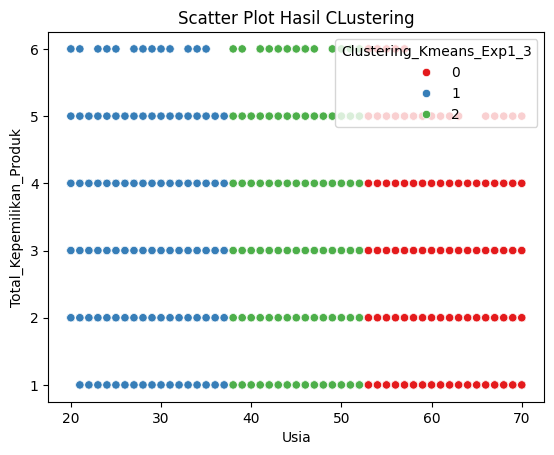

In [135]:
sns.scatterplot(data=data0, x='Usia', y='Total_Kepemilikan_Produk', hue='Clustering_Kmeans_Exp1_3', palette='Set1')
plt.title('Scatter Plot Hasil CLustering')
plt.show()

Secara demografik dilihat pembagi paling baik adalah menggunakan usia

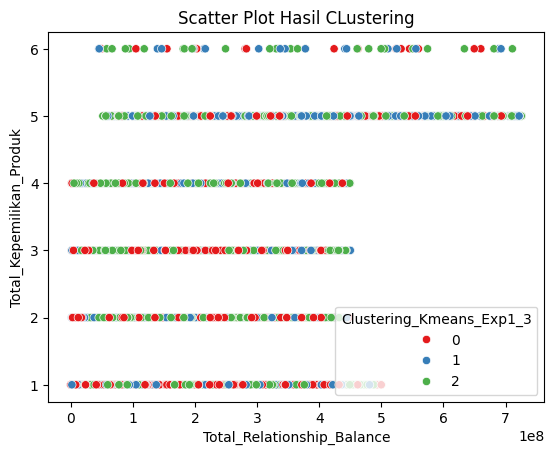

In [136]:
sns.scatterplot(data=data0, x='Total_Relationship_Balance', y='Total_Kepemilikan_Produk', hue='Clustering_Kmeans_Exp1_3', palette='Set1')
plt.title('Scatter Plot Hasil CLustering')
plt.show()

Jika dilihat dengan total balance terlihat ketidakjelasan pengelompokkan atau masih terdapat tumpang tindih

In [138]:
cluster_means = data0[['Usia','Jumlah_Anak','Produk_Tabungan','Produk_Deposito','Produk_Kartu_Kredit','Produk_Kredit_Rumah','Produk_Kredit_Kendaraan','Produk_Kredit_Dana_Tunai','Total_Kepemilikan_Produk','Total_Relationship_Balance','Clustering_Kmeans_Exp1_3']].groupby('Clustering_Kmeans_Exp1_3').mean()
print(cluster_means)
pd

                               Usia  Jumlah_Anak  Produk_Tabungan  \
Clustering_Kmeans_Exp1_3                                            
0                         58.840056     1.474672         0.657129   
1                         29.503177     1.191528         1.000000   
2                         45.571206     1.310945         0.983520   

                          Produk_Deposito  Produk_Kartu_Kredit  \
Clustering_Kmeans_Exp1_3                                         
0                                0.600844             0.338649   
1                                0.592436             0.308018   
2                                0.602612             0.336443   

                          Produk_Kredit_Rumah  Produk_Kredit_Kendaraan  \
Clustering_Kmeans_Exp1_3                                                 
0                                    0.618668                 0.168386   
1                                    0.586989                 0.157337   
2                          

<module 'pandas' from '/usr/local/lib/python3.11/dist-packages/pandas/__init__.py'>

Terlihat bahwa dari 3 cluster yang paling berbeda untuk usia.

## Group 0

In [139]:
data0[data0['Clustering_Kmeans_Exp1_3']==0][['Usia', 'Jumlah_Anak', 'Total_Kepemilikan_Produk', 'Total_Relationship_Balance']].describe(include='all')

,Usia,Jumlah_Anak,Total_Kepemilikan_Produk,Total_Relationship_Balance
count,2132.000000,2132.000000,2132.000000,2.132000e+03
mean,58.840056,1.474672,2.930113,2.389776e+08
std,5.133619,1.467245,1.041285,1.379077e+08
min,53.000000,0.000000,1.000000,1.028000e+03
25%,55.000000,0.000000,2.000000,1.266333e+08
50%,57.000000,1.000000,3.000000,2.328763e+08
75%,62.000000,3.000000,4.000000,3.493216e+08
max,70.000000,4.000000,6.000000,7.181097e+08


In [140]:
data0[data0['Clustering_Kmeans_Exp1_3']==0]['Area'].value_counts(normalize=True)

,proportion
Area,
Jakarta,0.478893
Bandung,0.166041
Solo,0.128987
Surabaya,0.126173
Jogja,0.072702
Bogor,0.027205


Paling banyak ada di daerah Jakarta

In [141]:
data0[data0['Clustering_Kmeans_Exp1_3']==0]['Vintage'].value_counts(normalize=True)

,proportion
Vintage,
2 - 3 Tahun,0.486867
< 1 Tahun,0.313321
> 4 Tahun,0.199812


In [142]:
data0[data0['Clustering_Kmeans_Exp1_3']==0]['Pendidikan'].value_counts(normalize=True)

,proportion
Pendidikan,
Sarjana,0.258443
SD,0.204972
SMA,0.180113
Tidak Sekolah Formal,0.101313
Magister,0.088180
SMP,0.083959
Doktor,0.083021


In [143]:
data0[data0['Clustering_Kmeans_Exp1_3']==0]['Jenis_Kelamin'].value_counts(normalize=True)

,proportion
Jenis_Kelamin,
Laki-laki,0.668386
Perempuan,0.331614


## Group 1

In [144]:
data0[data0['Clustering_Kmeans_Exp1_3']==1][['Usia', 'Jumlah_Anak', 'Total_Kepemilikan_Produk', 'Total_Relationship_Balance']].describe(include='all')

,Usia,Jumlah_Anak,Total_Kepemilikan_Produk,Total_Relationship_Balance
count,3305.000000,3305.000000,3305.000000,3.305000e+03
mean,29.503177,1.191528,3.243873,2.439352e+08
std,4.254972,1.480683,1.008655,1.452356e+08
min,20.000000,0.000000,1.000000,1.016565e+06
25%,26.000000,0.000000,3.000000,1.222784e+08
50%,30.000000,0.000000,3.000000,2.408255e+08
75%,33.000000,2.000000,4.000000,3.578412e+08
max,37.000000,4.000000,6.000000,7.228870e+08


In [145]:
data0[data0['Clustering_Kmeans_Exp1_3']==1]['Area'].value_counts(normalize=True)

,proportion
Area,
Jakarta,0.476248
Bandung,0.179728
Surabaya,0.126475
Solo,0.118306
Jogja,0.073222
Bogor,0.026021


In [146]:
data0[data0['Clustering_Kmeans_Exp1_3']==1]['Vintage'].value_counts(normalize=True)

,proportion
Vintage,
2 - 3 Tahun,0.501967
< 1 Tahun,0.293192
> 4 Tahun,0.204841


In [147]:
data0[data0['Clustering_Kmeans_Exp1_3']==1]['Pendidikan'].value_counts(normalize=True)

,proportion
Pendidikan,
Sarjana,0.274130
SMA,0.192436
SD,0.180333
Doktor,0.097731
Magister,0.087443
SMP,0.084720
Tidak Sekolah Formal,0.083207


In [148]:
data0[data0['Clustering_Kmeans_Exp1_3']==1]['Jenis_Kelamin'].value_counts(normalize=True)

,proportion
Jenis_Kelamin,
Laki-laki,0.640847
Perempuan,0.359153


## Group 2

In [149]:
data0[data0['Clustering_Kmeans_Exp1_3']==2][['Usia', 'Jumlah_Anak', 'Total_Kepemilikan_Produk', 'Total_Relationship_Balance']].describe(include='all')

,Usia,Jumlah_Anak,Total_Kepemilikan_Produk,Total_Relationship_Balance
count,3216.000000,3216.000000,3216.000000,3.216000e+03
mean,45.571206,1.310945,3.157960,2.377450e+08
std,4.278838,1.482616,1.045431,1.437032e+08
min,38.000000,0.000000,1.000000,1.384147e+06
25%,42.000000,0.000000,2.000000,1.166975e+08
50%,46.000000,1.000000,3.000000,2.309003e+08
75%,50.000000,3.000000,4.000000,3.468400e+08
max,52.000000,4.000000,6.000000,7.259942e+08


In [150]:
data0[data0['Clustering_Kmeans_Exp1_3']==2]['Area'].value_counts(normalize=True)

,proportion
Area,
Jakarta,0.484142
Bandung,0.161692
Surabaya,0.131530
Solo,0.112562
Jogja,0.081468
Bogor,0.028607


In [151]:
data0[data0['Clustering_Kmeans_Exp1_3']==2]['Vintage'].value_counts(normalize=True)

,proportion
Vintage,
2 - 3 Tahun,0.503731
< 1 Tahun,0.295398
> 4 Tahun,0.200871


In [152]:
data0[data0['Clustering_Kmeans_Exp1_3']==2]['Pendidikan'].value_counts(normalize=True)

,proportion
Pendidikan,
Sarjana,0.273321
SD,0.181592
SMA,0.180037
SMP,0.095771
Doktor,0.093905
Tidak Sekolah Formal,0.089552
Magister,0.085821


In [153]:
data0[data0['Clustering_Kmeans_Exp1_3']==2]['Jenis_Kelamin'].value_counts(normalize=True)

,proportion
Jenis_Kelamin,
Laki-laki,0.678483
Perempuan,0.321517


## **Kesimpulan**

Dari hasil *clustering*, yang menjadi pembeda adalah usia. Namun, bila hanya dari segi usia kita belum bisa melakukan segmentasi nasabah dengan baik (dilihat dari *silhouette score* yang masih belum mencapai 0.7). Hal yang dapat dilakukan ke depannya adalah dengan memperbanyak variabel dan melakukan iterasi lebih banyak.